In [2]:
%pip install torch torchvision opencv-python matplotlib scikit-learn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

In [4]:
def crop_black_border(img):
    import numpy as np
    
    img = np.array(img)
    gray = img.mean(axis=2)
    
    coords = np.where(gray > 10)
    
    y_min, y_max = coords[0].min(), coords[0].max()
    x_min, x_max = coords[1].min(), coords[1].max()
    
    return img[y_min:y_max, x_min:x_max]

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [6]:
train_dataset = datasets.ImageFolder("dataset/train", transform=train_transform)
val_dataset = datasets.ImageFolder("dataset/val", transform=val_transform)
test_dataset = datasets.ImageFolder("dataset/test", transform=val_transform)

In [7]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [8]:
print(train_dataset.class_to_idx)

{'negative': 0, 'positive': 1}


In [9]:
model = torchvision.models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 2)

c:\Users\Asus A1404\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Asus A1404\AppData\Local\Programs\Python\Python314\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

weights = torch.tensor([2.7, 1.0]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [11]:
train_losses = []
val_losses = []

for epoch in range(10):

    # TRAIN
    model.train()
    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

Epoch 1: Train Loss 0.2898 | Val Loss 0.4596
Epoch 2: Train Loss 0.1616 | Val Loss 0.1186
Epoch 3: Train Loss 0.0839 | Val Loss 0.1223
Epoch 4: Train Loss 0.0985 | Val Loss 0.0863
Epoch 5: Train Loss 0.0601 | Val Loss 0.0836
Epoch 6: Train Loss 0.0533 | Val Loss 0.0629
Epoch 7: Train Loss 0.0525 | Val Loss 0.1582
Epoch 8: Train Loss 0.0400 | Val Loss 0.1262
Epoch 9: Train Loss 0.0551 | Val Loss 0.0689
Epoch 10: Train Loss 0.0248 | Val Loss 0.1015


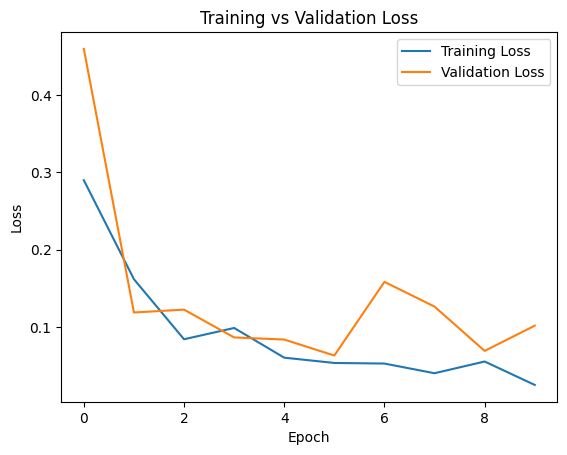

In [13]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [15]:
from sklearn.metrics import classification_report

y_true = []
y_pred = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.99      0.98      0.98        82

    accuracy                           0.97       112
   macro avg       0.96      0.97      0.97       112
weighted avg       0.97      0.97      0.97       112



In [16]:
torch.save(model.state_dict(), "glaucoma_model.pth")

In [17]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F

y_scores = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)[:,1]

        y_scores.extend(probs.cpu().numpy())

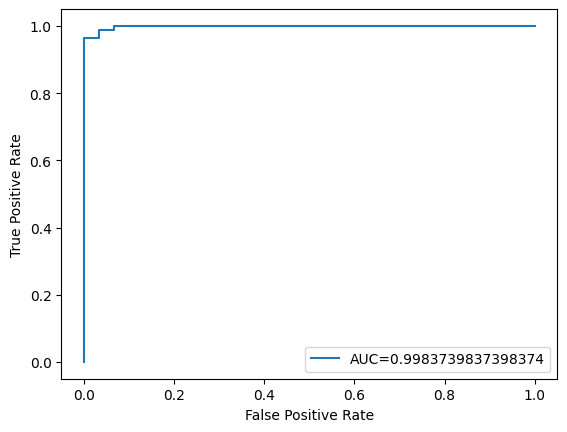

In [18]:
from matplotlib import pyplot as plt


fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC="+str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [19]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_true, y_scores)
print("AUC:", auc)

AUC: 0.9983739837398374


GRAD-CAM

In [20]:
%pip install grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from torchvision import models, transforms
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18()

model.fc = torch.nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load("glaucoma_model.pth", map_location=device))

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
target_layer = model.layer4[-1]

In [24]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

img = Image.open("dataset/test/negative/275_1.jpg").convert("RGB")

input_tensor = transform(img).unsqueeze(0)

In [25]:
img_np = np.array(img.resize((224,224))) / 255.0

In [26]:
cam = GradCAM(model=model, target_layers=[target_layer])

grayscale_cam = cam(
    input_tensor=input_tensor,
    aug_smooth=True,
    eigen_smooth=True
)

cam_image = show_cam_on_image(img_np, grayscale_cam[0], use_rgb=True)

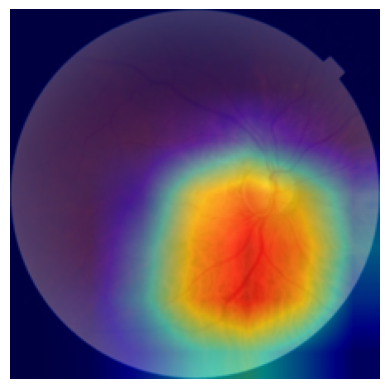

In [27]:
plt.imshow(cam_image)
plt.axis("off")
plt.show()